In [14]:
import pandas as pd
import seaborn as sns

In [3]:
mutac_df3 = pd.read_feather("../data/joined-counts.df3.zstd8.feather")
mutac_df3.shape

(216196, 179)

In [4]:
hamburg_df_part0 = pd.read_feather("../data/hamburg/hamburg-joined-counts.4.0.feather")
hamburg_df_part0.shape

(69360055, 64)

In [6]:
hamburg_df_part0 = hamburg_df_part0[hamburg_df_part0.index.isin(mutac_df3.index)]
hamburg_df_part0.shape

(26001, 64)

In [8]:
hamburg_df_part0.to_feather("../data/hamburg/hamburg-part0-mutac-df3-joined.feather")

In [2]:
hamburg_df_part1 = pd.read_feather("../data/hamburg/hamburg-joined-counts.4.1.feather")
hamburg_df_part1.shape

(61296697, 56)

In [4]:
hamburg_df_part1 = hamburg_df_part1[hamburg_df_part1.index.isin(mutac_df3.index)]
hamburg_df_part1.shape

(22565, 56)

In [5]:
hamburg_df_part1.to_feather("../data/hamburg/hamburg-part1-mutac-df3-joined.feather")

In [6]:
df_joined = pd.read_feather("../data/hamburg/hamburg-part0-mutac-df3-joined.feather").join(
    pd.read_feather("../data/hamburg/hamburg-part1-mutac-df3-joined.feather"),
    how="outer",
)
df_joined.shape

(30141, 120)

In [7]:
df_joined.to_feather("../data/hamburg/hamburg-mutac-df3-joined.feather")

In [9]:
df_joined = pd.read_feather("../data/hamburg/hamburg-mutac-df3-joined.feather")
df_joined.shape

(30141, 120)

In [11]:
df_joined.fillna(0, inplace=True)
df_joined.head()

,C_LC_1,C_LC_10,C_LC_100,C_LC_101,C_LC_102,C_LC_103,C_LC_104,C_LC_105,C_LC_106,C_LC_107,...,C_LC_90,C_LC_91,C_LC_92,C_LC_93,C_LC_94,C_LC_95,C_LC_96,C_LC_97,C_LC_98,C_LC_99
kmer,,,,,,,,,,,,,,,,,,,,,
AAAAAAAAAAAAAAAAAAGCATC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAAAAAAAAAAAAAAAAGTCCT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAAAAAAAAAAAAAAAATTCGA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0
AAAAAAAAAAAAAAAAACATTCT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AAAAAAAAAAAAAAAAACCTTCT,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
def describe_all_values(df: pd.DataFrame):
    return pd.Series(df.values.flatten()).describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99],
    )

In [13]:
describe_all_values(df_joined)

count    3.616920e+06
mean     1.237477e+00
std      6.969371e+00
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
10%      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
90%      6.000000e+00
95%      8.000000e+00
99%      1.600000e+01
max      4.650000e+02
dtype: float64

Text(0.5, 1.0, 'Kmer Presense Distribution')

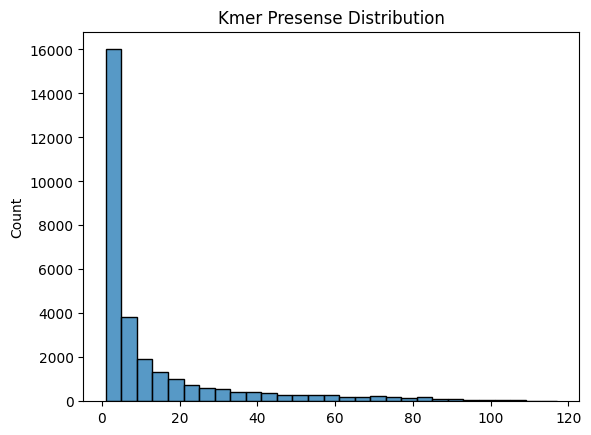

In [16]:
sns.histplot((df_joined > 0).sum(axis=1), binwidth=4).set_title("Kmer Presense Distribution")

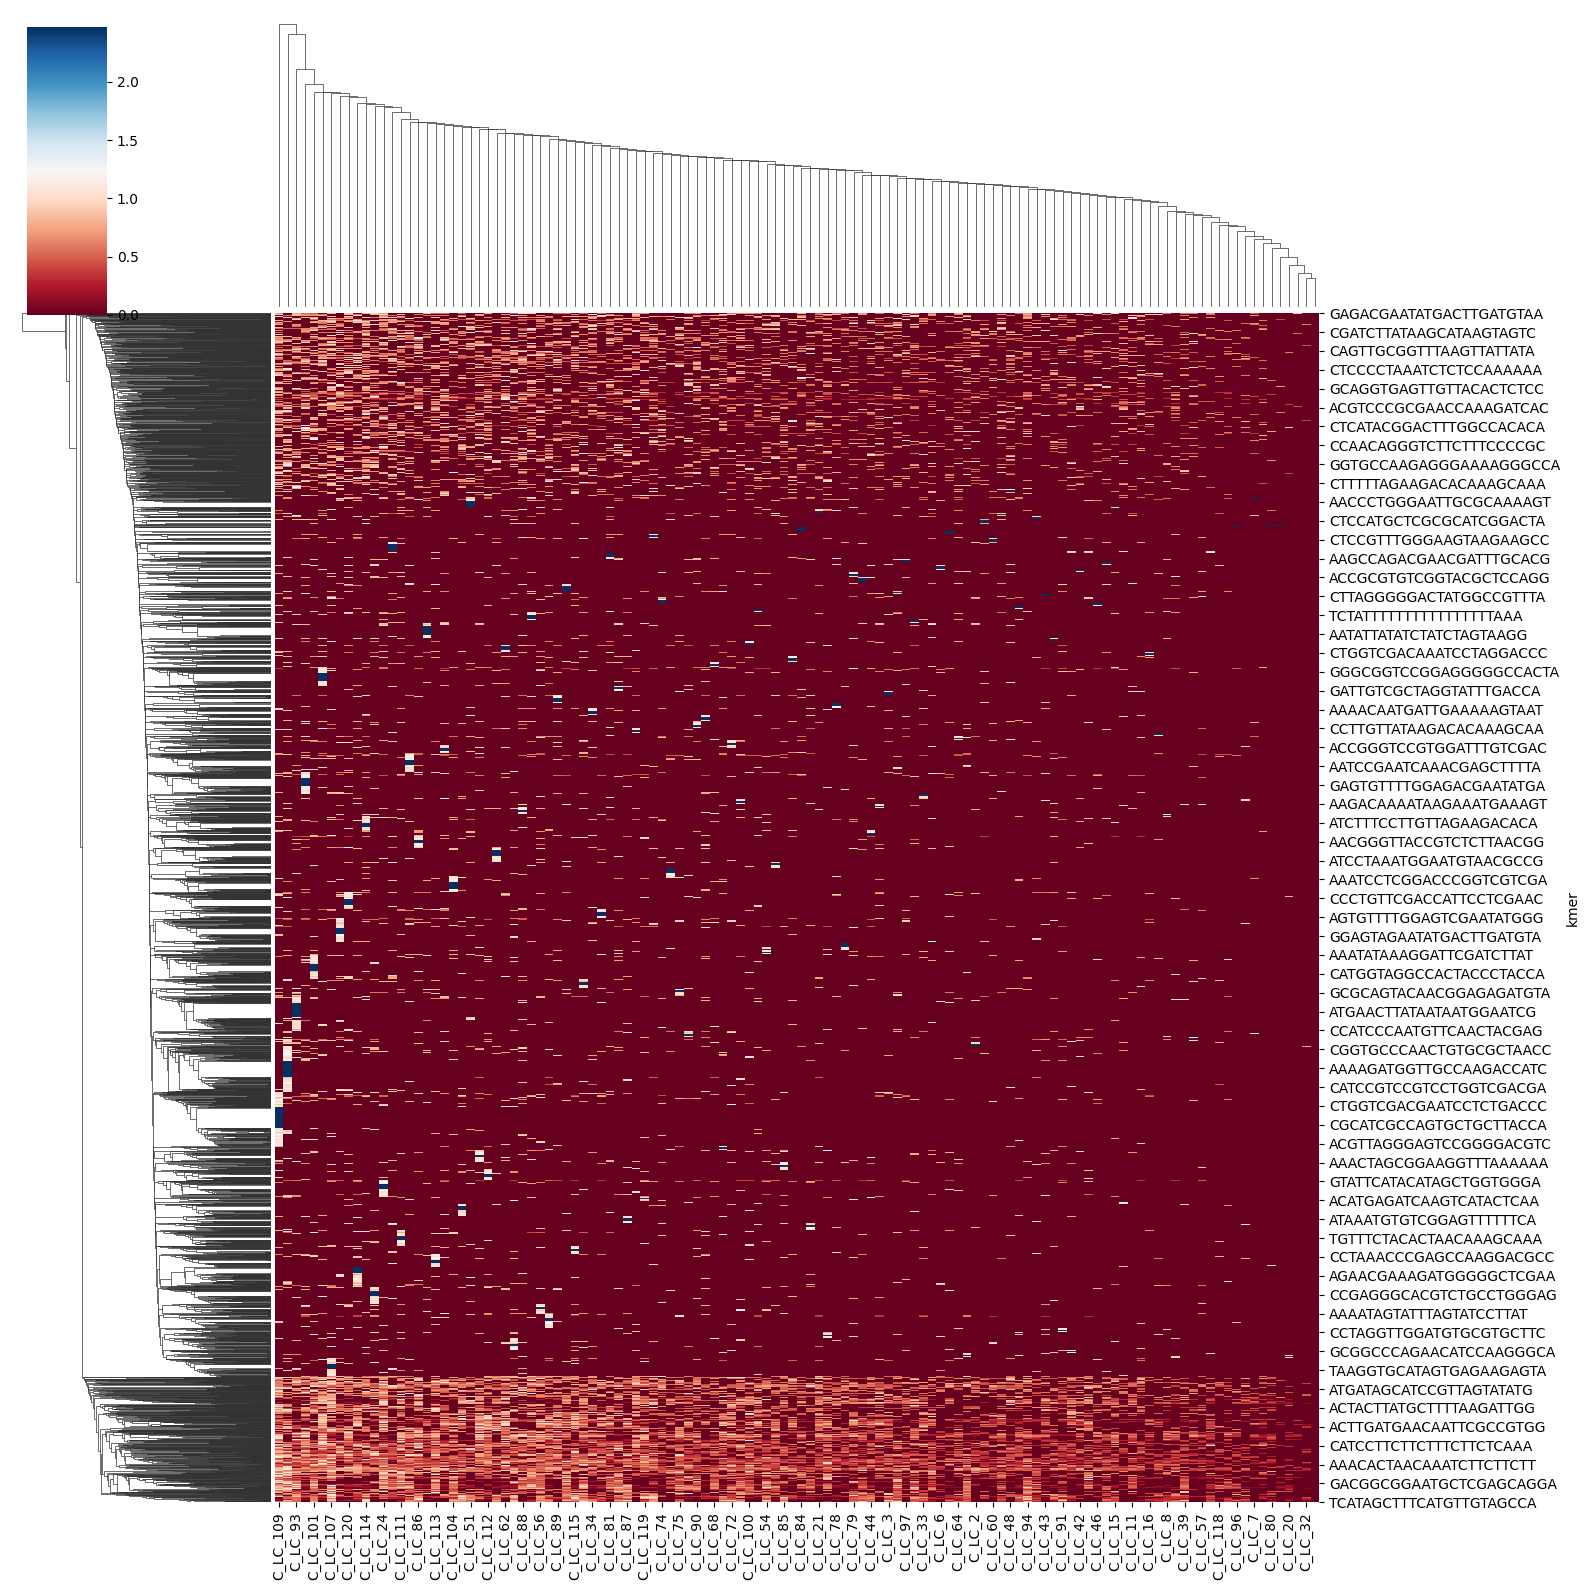

In [20]:
sampled = df_joined.sample(n=4096)
# Normalize by 99th percentile
sampled = sampled.div(sampled.quantile(0.995, axis=1), axis=0)
sns.clustermap(
    sampled,
    cmap="RdBu",
    figsize=(16, 16),
)

In [17]:
df_genotype = pd.read_csv("../data/hamburg/C_LC_cen_genotype.csv", index_col=0)
df_genotype.shape

(119, 5)

In [18]:
df_genotype.head()

,1,2,3,4,5
Sample,,,,,
C-LC-1,A,H,H,A,H
C-LC-10,A,H,H,H,H
C-LC-100,A,H,H,H,H
C-LC-102,A,A,A,A,A
C-LC-103,A,A,H,A,H


In [22]:
df_genotype.index = df_genotype.index.str.removeprefix("C-LC-")
df_genotype.head()

,1,2,3,4,5
Sample,,,,,
1,A,H,H,A,H
10,A,H,H,H,H
100,A,H,H,H,H
102,A,A,A,A,A
103,A,A,H,A,H


In [25]:
df_genotype = df_genotype.map(lambda x: {"A": 0, "H": 1}.get(x, x))
df_genotype.head()

,1,2,3,4,5
Sample,,,,,
1,0,1,1,0,1
10,0,1,1,1,1
100,0,1,1,1,1
102,0,0,0,0,0
103,0,0,1,0,1


In [30]:
for i in range(1, 121):
    if not str(i) in df_genotype.index:
        print(f"Missing {i} in genotype index")

Missing 73 in genotype index


In [31]:
df_joined.columns = df_joined.columns.str.removeprefix("C_LC_")
df_joined.drop(columns=["73"], inplace=True)
df_joined.shape

(30141, 119)

In [32]:
df = df_joined.transpose()
df.head()

kmer,AAAAAAAAAAAAAAAAAAGCATC,AAAAAAAAAAAAAAAAAAGTCCT,AAAAAAAAAAAAAAAAAATTCGA,AAAAAAAAAAAAAAAAACATTCT,AAAAAAAAAAAAAAAAACCTTCT,AAAAAAAAAAAAAAAAACGGAGT,AAAAAAAAAAAAAAAAACTGTAA,AAAAAAAAAAAAAAAAAGACCCA,AAAAAAAAAAAAAAAAAGCAATT,AAAAAAAAAAAAAAAAAGCGATC,...,TTTTTATAAATAAAAAAAAAAAA,TTTTTCACACCGTAAAAAAAAAA,TTTTTTCACACCGTAAAAAAAAA,TTTTTTCCAAAAAAAAAAAAAAA,TTTTTTTAGTTGAAAAAAAAAAA,TTTTTTTCACACCGTAAAAAAAA,TTTTTTTGATAAAAAAAAAAAAA,TTTTTTTTGATAAAAAAAAAAAA,TTTTTTTTTAGAAAAAAAAAAAA,TTTTTTTTTTAGAAAAAAAAAAA
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,0.0,0.0


In [33]:
df = df.join(df_genotype, how="inner")
df.shape

(119, 30146)

In [34]:
df.head()

,AAAAAAAAAAAAAAAAAAGCATC,AAAAAAAAAAAAAAAAAAGTCCT,AAAAAAAAAAAAAAAAAATTCGA,AAAAAAAAAAAAAAAAACATTCT,AAAAAAAAAAAAAAAAACCTTCT,AAAAAAAAAAAAAAAAACGGAGT,AAAAAAAAAAAAAAAAACTGTAA,AAAAAAAAAAAAAAAAAGACCCA,AAAAAAAAAAAAAAAAAGCAATT,AAAAAAAAAAAAAAAAAGCGATC,...,TTTTTTTCACACCGTAAAAAAAA,TTTTTTTGATAAAAAAAAAAAAA,TTTTTTTTGATAAAAAAAAAAAA,TTTTTTTTTAGAAAAAAAAAAAA,TTTTTTTTTTAGAAAAAAAAAAA,1,2,3,4,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,1,0,1
10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,1,1,1
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,1,1,1,1
101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1,1,0,1,0
102,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,6.0,7.0,0.0,0.0,0,0,0,0,0


In [38]:
df_corr = df.corr()
df_corr.shape

(30146, 30146)

In [39]:
df_corr = df_corr.iloc[:-5, -5:]
df_corr.shape

(30141, 5)

In [40]:
df_corr.head(10)

,1,2,3,4,5
AAAAAAAAAAAAAAAAAAGCATC,-0.098559,0.071959,0.053530,0.030073,-0.068923
AAAAAAAAAAAAAAAAAAGTCCT,-0.046776,0.036094,-0.109738,-0.136547,-0.049547
AAAAAAAAAAAAAAAAAATTCGA,-0.027280,-0.038109,0.097718,-0.108603,0.040317
AAAAAAAAAAAAAAAAACATTCT,-0.091287,-0.099304,-0.120189,0.108143,0.100999
AAAAAAAAAAAAAAAAACCTTCT,0.011123,0.120840,0.099842,0.031240,0.143014
AAAAAAAAAAAAAAAAACGGAGT,0.126404,-0.046480,-0.163650,-0.017072,0.048661
AAAAAAAAAAAAAAAAACTGTAA,-0.127090,-0.138252,0.098165,0.046695,-0.116816
AAAAAAAAAAAAAAAAAGACCCA,0.092834,0.085340,-0.120189,-0.078365,-0.083907
AAAAAAAAAAAAAAAAAGCAATT,-0.091287,-0.099304,0.070511,0.108143,-0.083907
AAAAAAAAAAAAAAAAAGCGATC,-0.091287,-0.099304,0.070511,0.108143,-0.083907


Text(0.5, 1.0, 'Correlation Distribution')

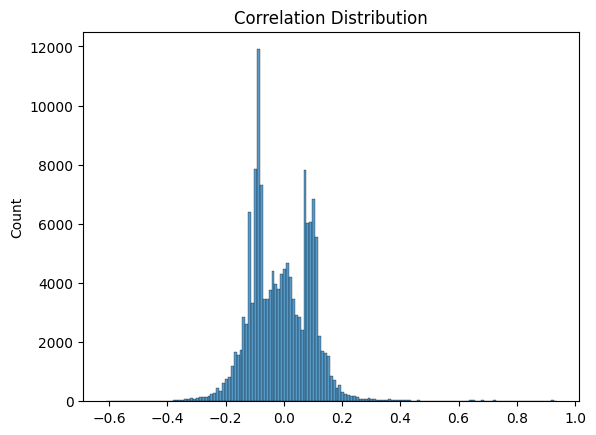

In [52]:
sns.histplot(df_corr.values.flatten(), binwidth=0.01).set_title("Correlation Distribution")

In [56]:
df_corr_filtered = df_corr[df_corr.abs().max(axis=1) > 0.5]
df_corr_filtered.shape

(836, 5)

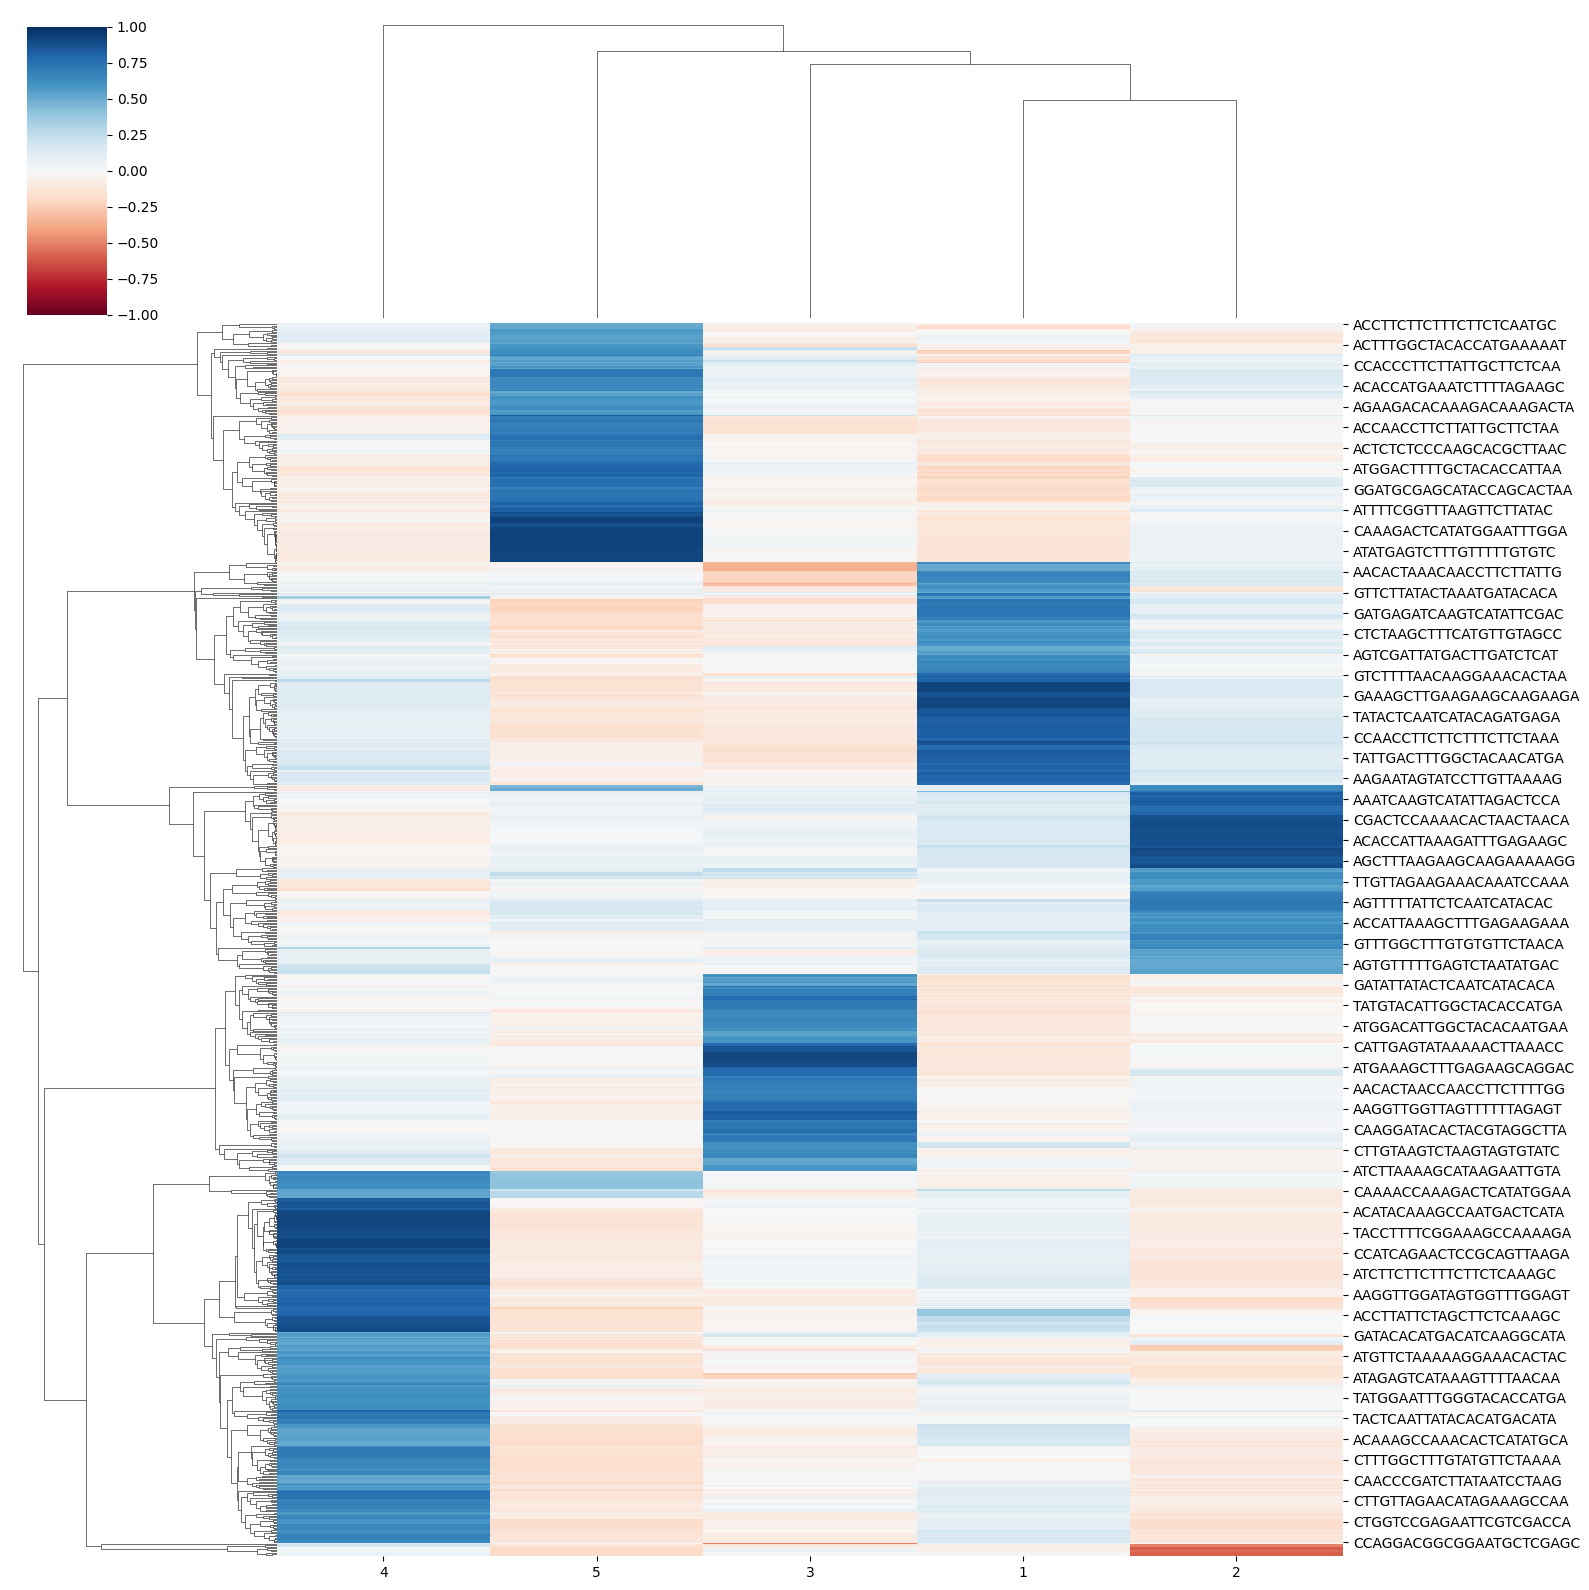

In [57]:
sns.clustermap(
    df_corr_filtered,
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)

In [53]:
df_corr_filtered = df_corr[df_corr.abs().max(axis=1) > 0.25]
df_corr_filtered.shape

(3264, 5)

In [54]:
df_corr_filtered

,1,2,3,4,5
AAAAAAAAAAAAAAATTAGAGGG,0.119974,-0.005240,-0.069355,0.315564,0.015844
AAAAAAACAAAGCCAAAGACTCA,0.282916,-0.008681,0.032728,-0.018250,-0.137962
AAAAAACTAACAAACCTTCTTCT,0.186174,0.050223,0.351326,-0.032858,0.116054
AAAAAACTAACCAACCTTCTTTT,-0.090174,-0.353093,-0.056794,0.289984,0.057835
AAAAAAGAATAGATACGATTGAA,0.078750,0.054118,-0.445839,0.056888,-0.088854
...,...,...,...,...,...
TTTGACTTTGTGTCTTCTAAAAA,-0.255399,-0.160192,0.026575,-0.026291,-0.014470
TTTGGCTTTGTATGTTCTAAAAA,-0.114839,-0.101607,0.023528,0.628927,-0.138422
TTTGGCTTTGTGTCTTATAAAAA,0.118529,0.596176,0.007063,-0.057720,0.130703
TTTGTGTCTTCTAAAAAGGAAAA,-0.092669,0.133916,0.021513,0.061330,0.252590


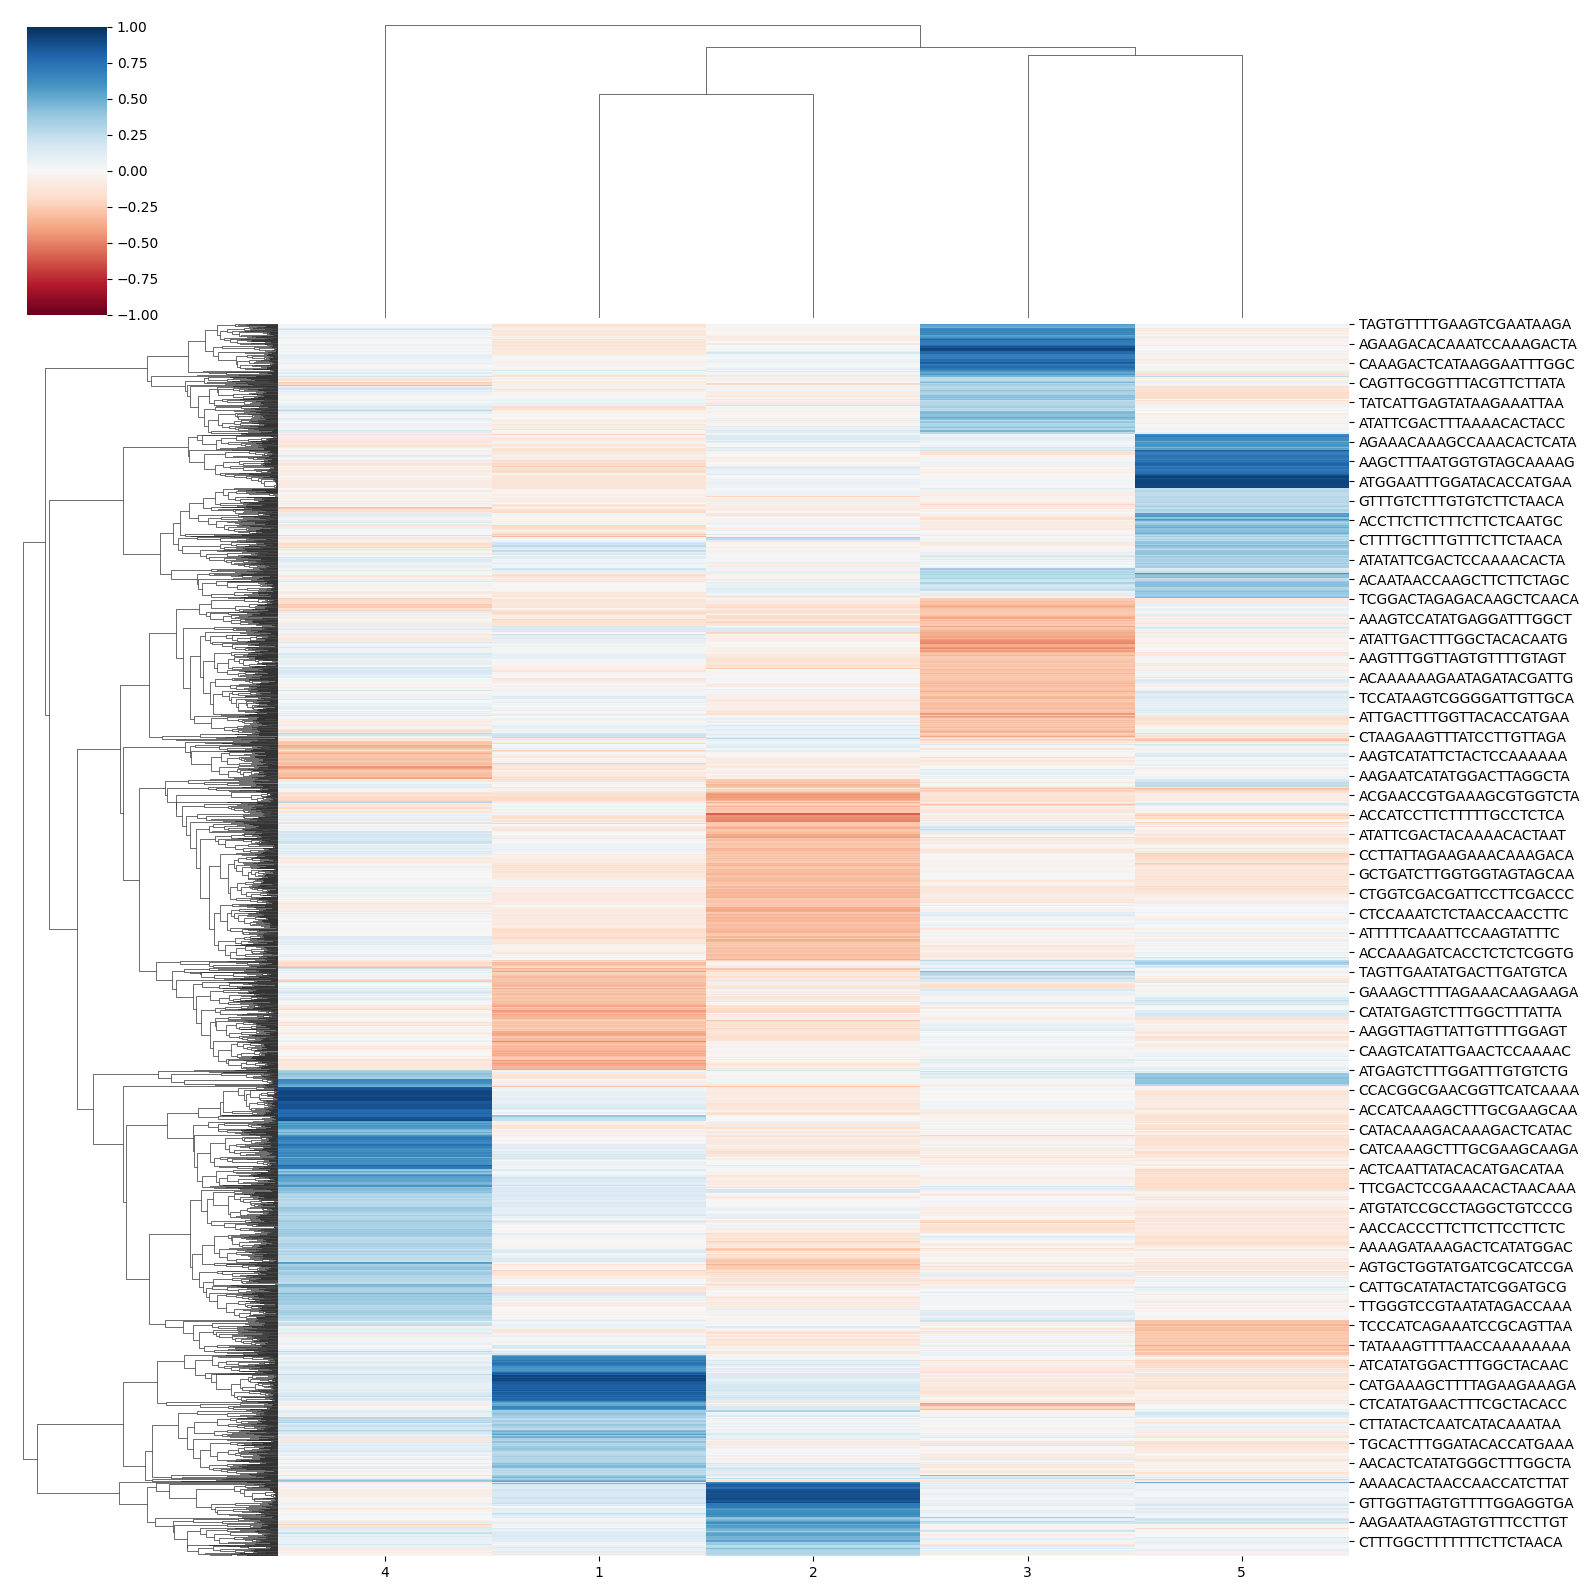

In [55]:
sns.clustermap(
    df_corr_filtered,
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)

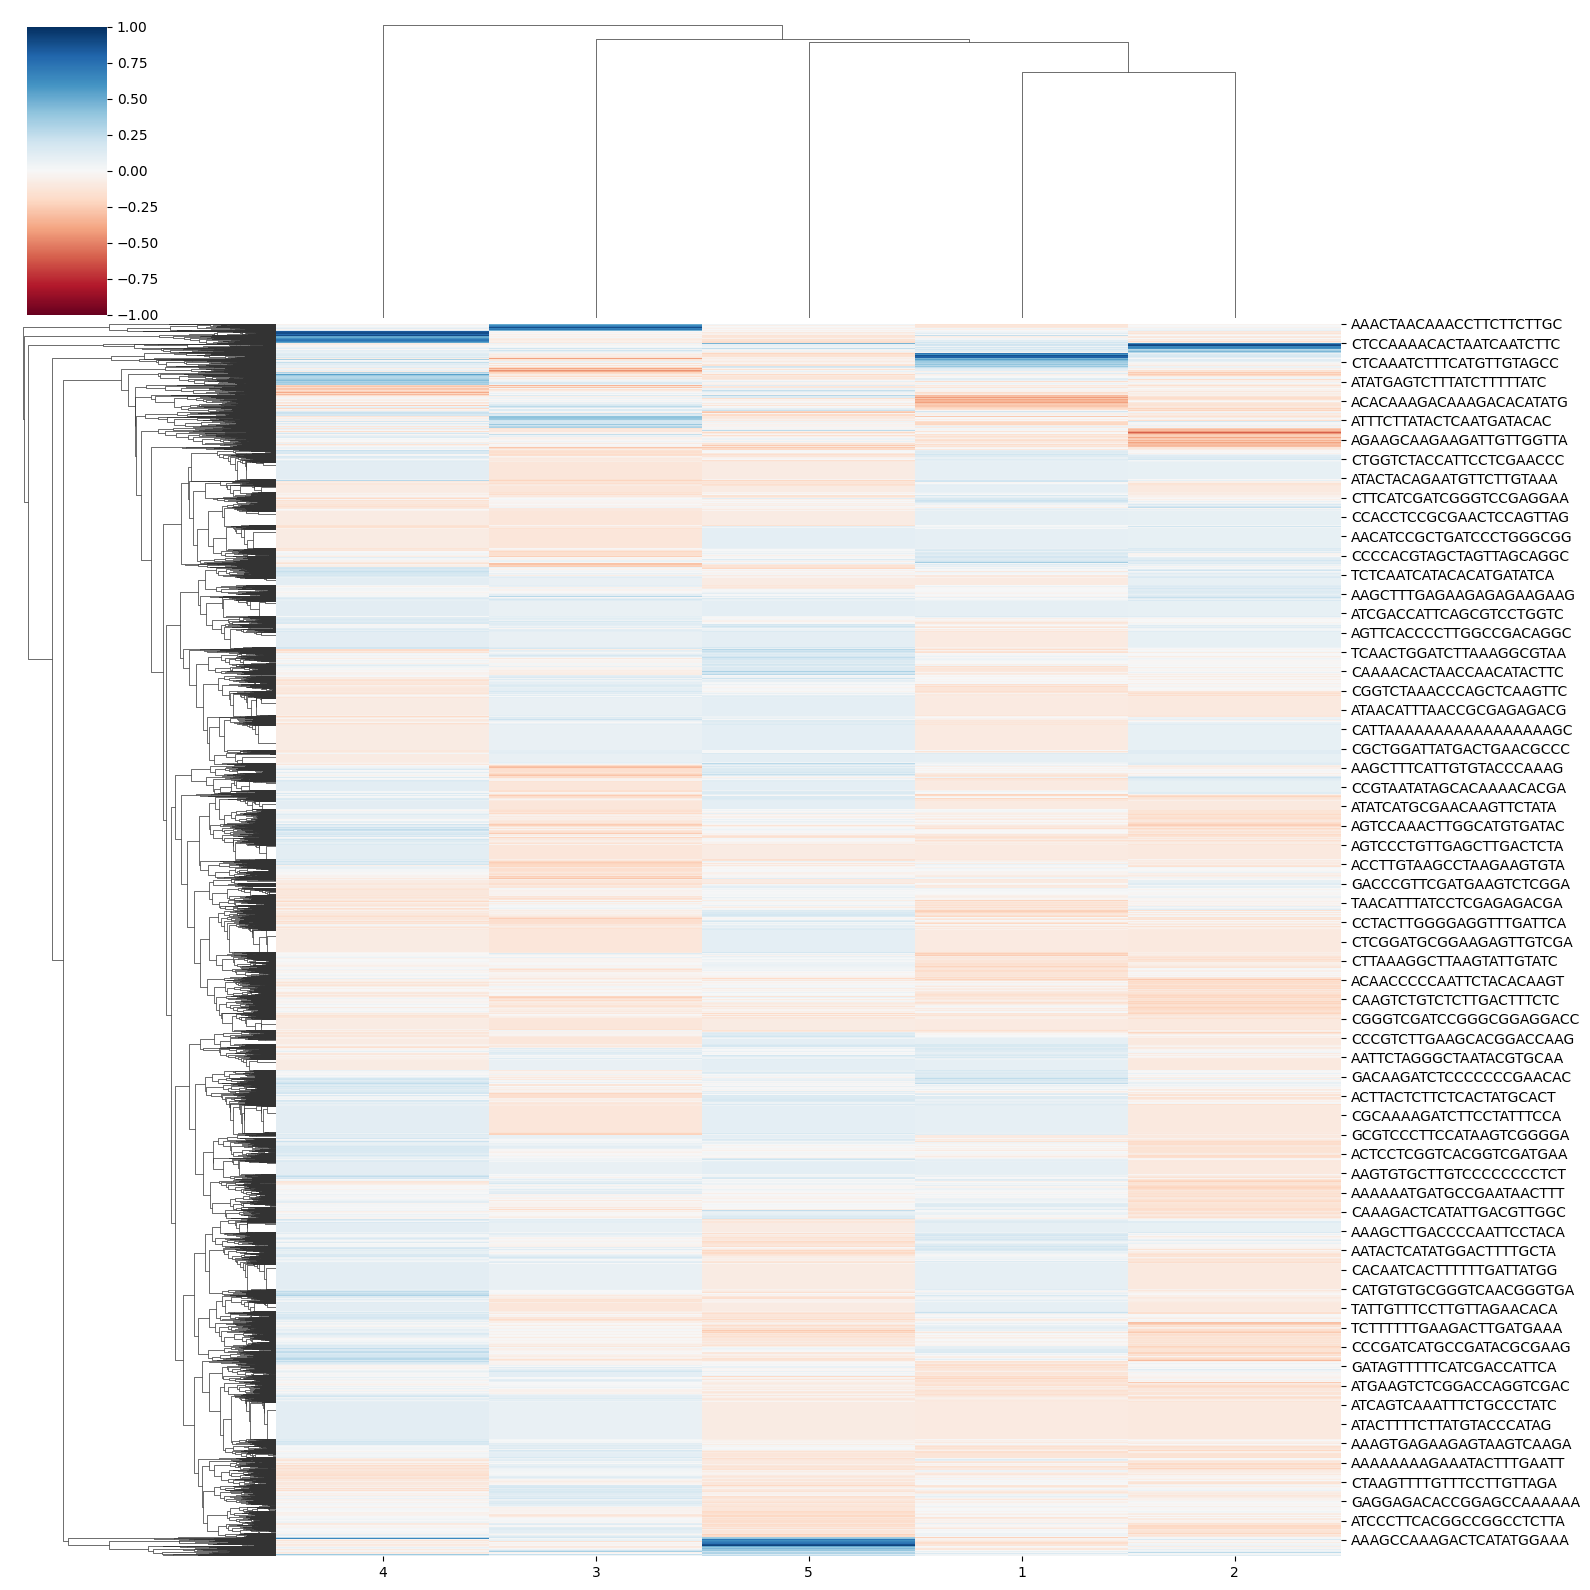

In [60]:

sns.clustermap(
    df_corr[df_corr.abs().max(axis=1) > 0.1],
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)

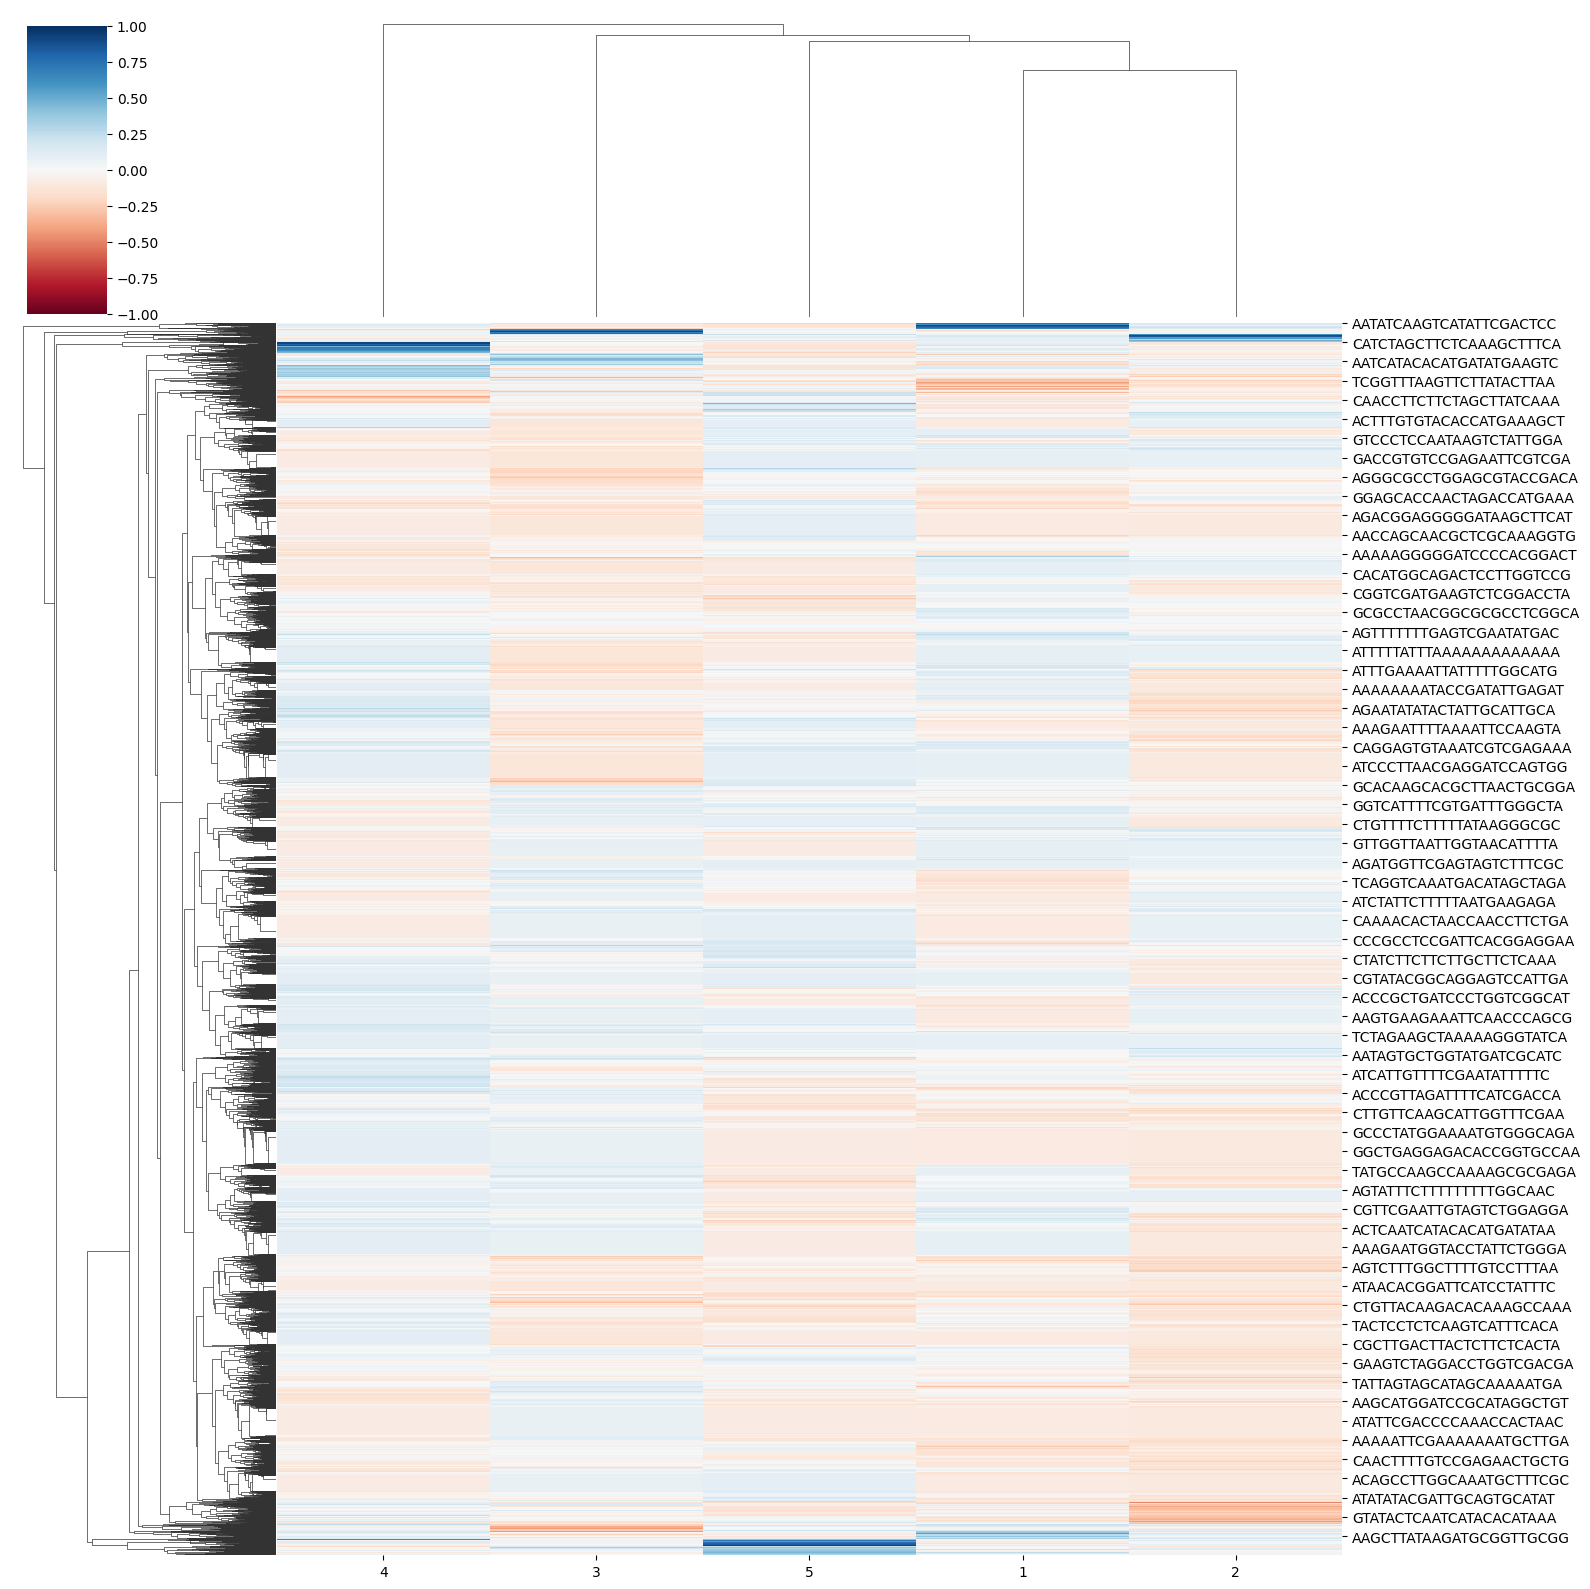

In [58]:
sns.clustermap(
    df_corr,
    cmap="RdBu",
    figsize=(16, 16),
    vmin=-1,
    vmax=1,
)